# Phase 4 — Explainability (SHAP)

Global **beeswarm** summary on the held-out test set, a short **modifiable vs. non-modifiable** attribution view, and **waterfall** plots for one high-risk and one low-risk patient using the saved XGBoost pipeline (`models/xgboost_pipeline.joblib`). Run `notebook/modeling.ipynb` first if that file is missing.


In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split

ROOT = Path.cwd().resolve()
if ROOT.name == "notebook":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.preprocessing import (
    MODIFIABLE_FEATURES,
    NON_MODIFIABLE_FEATURES,
    load_heart_csv,
)

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

MODEL_PATH = ROOT / "models" / "xgboost_pipeline.joblib"
if not MODEL_PATH.is_file():
    raise FileNotFoundError(
        f"Missing {MODEL_PATH}. Train and save the model in notebook/modeling.ipynb first."
    )

pipe = joblib.load(MODEL_PATH)
DATA_PATH = ROOT / "data" / "heart-disease.csv"
X, y = load_heart_csv(DATA_PATH)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

prep = pipe.named_steps["prep"]
X_test_t = prep.transform(X_test)
feature_names = list(prep.get_feature_names_out())

clf = pipe.named_steps["clf"]
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_t)

if isinstance(shap_values, list):
    shap_values = np.asarray(shap_values[1])

expected_value = explainer.expected_value
if isinstance(expected_value, np.ndarray) and expected_value.size > 1:
    base_value = float(expected_value.ravel()[-1])
else:
    base_value = float(np.ravel(expected_value)[0])

proba = pipe.predict_proba(X_test)[:, 1]
idx_high = int(np.argmax(proba))
idx_low = int(np.argmin(proba))

print("Test rows:", len(X_test))
print("Highest predicted risk — index", idx_high, "p=", round(float(proba[idx_high]), 4))
print("Lowest predicted risk — index", idx_low, "p=", round(float(proba[idx_low]), 4))


Test rows: 61
Highest predicted risk — index 42 p= 0.9887
Lowest predicted risk — index 53 p= 0.0209


/Users/gabrielesantoro/heart-risk-advisor/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Global view (beeswarm)

Each point is one patient on one feature: **color** is the feature value (high vs low), **horizontal position** is SHAP impact on the model’s output (higher predicted risk to the right). **ST depression (`oldpeak`)** and exercise-related variables often dominate—consistent with stress-test ischemia patterns seen in cardiology.

> **Caption:** The beeswarm ranks which engineered inputs move the XGBoost score the most on the test split; wide spread along the x-axis means that feature separates high- from low-risk predictions.


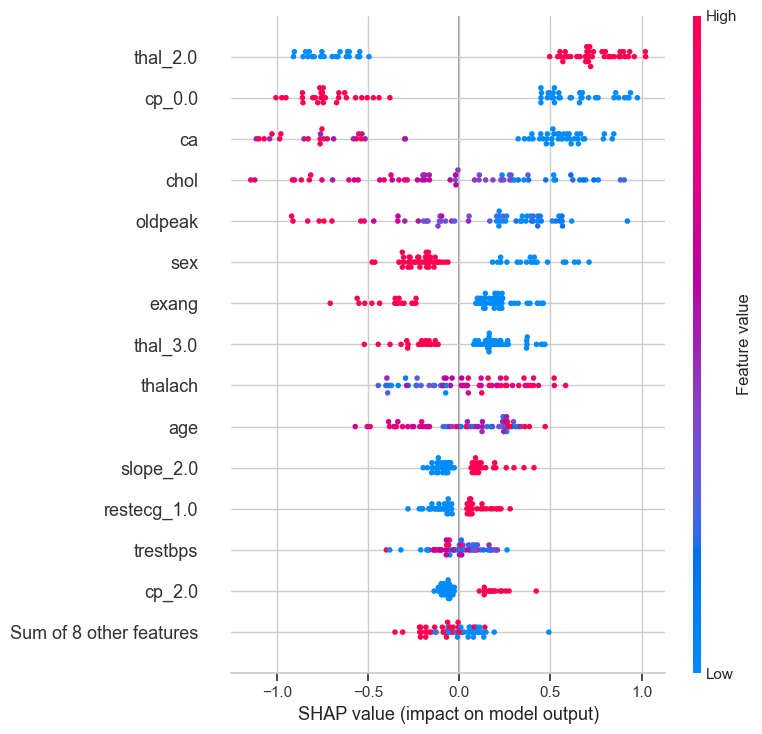

In [2]:
explanation = shap.Explanation(
    shap_values,
    base_values=base_value,
    data=X_test_t,
    feature_names=feature_names,
)

plt.figure(figsize=(9, 6))
shap.plots.beeswarm(explanation, max_display=15, show=False)
plt.tight_layout()
plt.show()


### Modifiable vs. non-modifiable drivers (mean |SHAP|)

We group transformed columns by whether the **raw** attribute is in `NON_MODIFIABLE_FEATURES` (**age**, **sex**) or `MODIFIABLE_FEATURES` (all other clinical inputs). One-hot columns are attributed to their base name (e.g. `cp_2` → modifiable **cp**).

> **Caption:** If modifiable factors account for most of the absolute SHAP mass, that supports a “what can I change?” narrative for lifestyle and risk-factor counseling (always alongside clinician judgment).


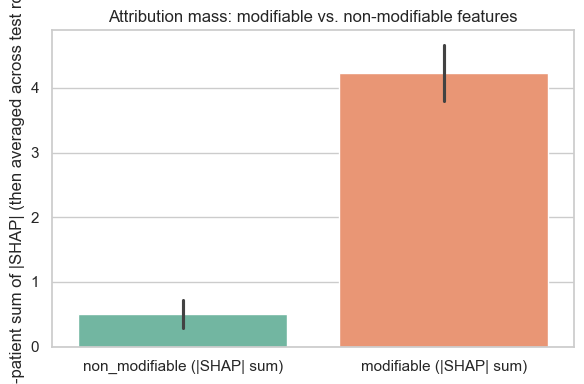

MODIFIABLE_FEATURES (raw): ('cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal')
NON_MODIFIABLE_FEATURES (raw): ('age', 'sex')


In [3]:
def raw_base_name(fname: str) -> str:
    return str(fname).split("_")[0]


def is_nonmodifiable(fname: str) -> bool:
    base = raw_base_name(fname)
    return base in NON_MODIFIABLE_FEATURES


mask_nm = np.array([is_nonmodifiable(f) for f in feature_names])
abs_shap = np.abs(shap_values)

contrib_nm = abs_shap[:, mask_nm].sum(axis=1)
contrib_m = abs_shap[:, ~mask_nm].sum(axis=1)

compare = (
    pd.DataFrame(
        {
            "non_modifiable (|SHAP| sum)": contrib_nm,
            "modifiable (|SHAP| sum)": contrib_m,
        }
    )
    .melt(var_name="group", value_name="mean_abs_shap_contribution")
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(
    data=compare,
    x="group",
    y="mean_abs_shap_contribution",
    hue="group",
    dodge=False,
    palette="Set2",
    ax=ax,
    errorbar="sd",
)
ax.set_ylabel("Per-patient sum of |SHAP| (then averaged across test rows)")
ax.set_xlabel("")
ax.set_title("Attribution mass: modifiable vs. non-modifiable features")
plt.tight_layout()
plt.show()

print("MODIFIABLE_FEATURES (raw):", MODIFIABLE_FEATURES)
print("NON_MODIFIABLE_FEATURES (raw):", NON_MODIFIABLE_FEATURES)


### Local explanations — waterfall plots

**Waterfall:** each bar shows how a feature value pushes the model output from the **base rate** (`E[f(x)]`) toward the predicted log-odds for that patient.


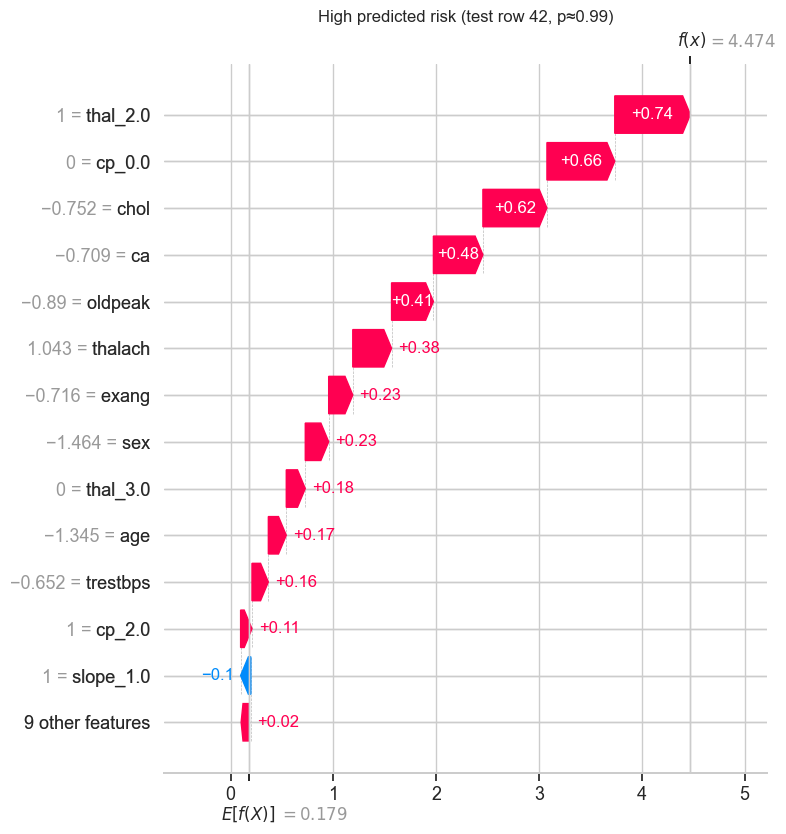

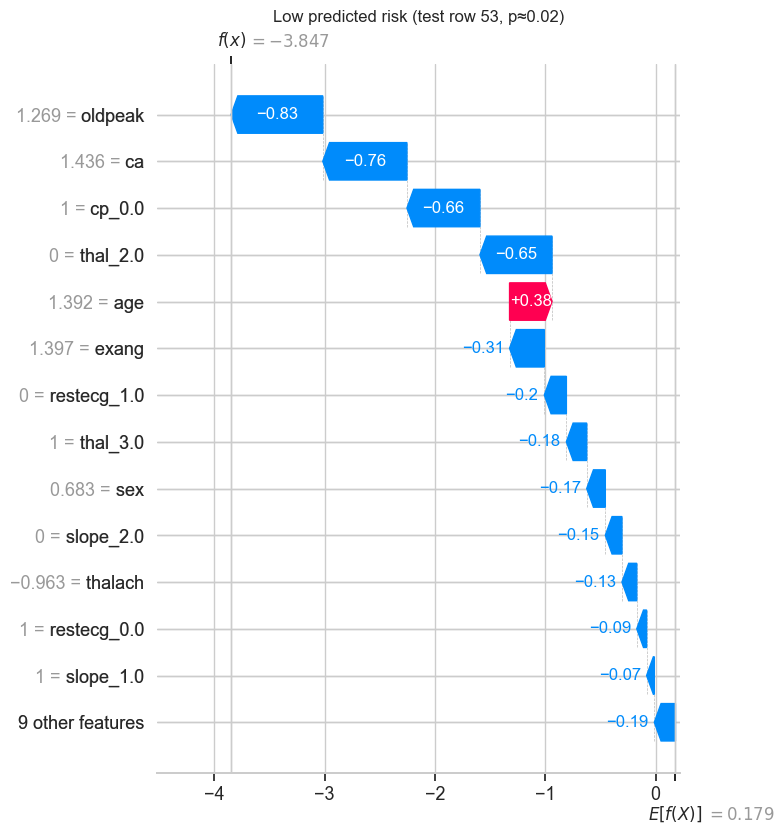

In [4]:
def waterfall_for_row(row_idx: int, title: str) -> None:
    row_shap = shap_values[row_idx]
    row_data = X_test_t.iloc[row_idx] if hasattr(X_test_t, "iloc") else X_test_t[row_idx]
    exp_row = shap.Explanation(
        values=row_shap,
        base_values=base_value,
        data=row_data,
        feature_names=feature_names,
    )
    plt.figure(figsize=(9, 6))
    shap.plots.waterfall(exp_row, max_display=14, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


waterfall_for_row(
    idx_high,
    f"High predicted risk (test row {idx_high}, p≈{proba[idx_high]:.2f})",
)

waterfall_for_row(
    idx_low,
    f"Low predicted risk (test row {idx_low}, p≈{proba[idx_low]:.2f})",
)
